Creat squeance - normalize - feture eningering

In [13]:
TICKER = "TSCO.L" 
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
def scalevalue(dataset):
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(dataset)
    return scaled_data,scaler

# Create the training data set 
# Create the scaled training data set
def creatdataset(df, window_size=60,feature_size=1):
    # dataset=conv2value(df)
    dataset = df#[['Close']]
    # dataset = dataset.values
    scaled_data,scaler=scalevalue(dataset)
    
    training_data_len = int(np.ceil( len(dataset) * .9 ))
    train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
    x_train = []
    y_train = []
    

    for i in range(window_size, len(train_data)):
        if feature_size == 1:
            x_train.append(train_data[i-window_size:i, 0])
            y_train.append(train_data[i, 0])
        else:
            x_train.append(train_data[i-window_size:i, 0:feature_size])
            y_train.append(train_data[i, 0])
        #if i<= 61:
            #print(x_train)
            #print(y_train)
            #print()
        # Create the testing data set
        # Convert the x_train and y_train to numpy arrays 
    x_train, y_train = np.array(x_train), np.array(y_train)

    # Reshape the data
    if feature_size > 1:
        x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], feature_size ))
    else:
        x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
    # x_train.shape
    
# Create a new array containing scaled values from index 1543 to 2002 
    test_data = scaled_data[training_data_len - window_size: , :]
# Create the data sets x_test and y_test
    x_test = []
    y_test = scaled_data[training_data_len:, 0]
    #print(y_test)
    for i in range(window_size, len(test_data)):
        if feature_size == 1:
            x_test.append(test_data[i-window_size:i, 0])
        else:
            x_test.append(test_data[i-window_size:i, 0:feature_size])
    
# Convert the data to a numpy array
    x_test = np.array(x_test)

# Reshape the 
    if feature_size > 1:
        x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], feature_size ))
    else:
        x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))
    
    return x_train, y_train,x_test,y_test,scaler
###############
def make_features_from_multiindex(df_multi: pd.DataFrame, ticker: str = TICKER) -> pd.DataFrame:
    # 1) Select one ticker from MultiIndex (Price, Ticker)
    # df = df_multi.xs(key=ticker, level="Ticker", axis=1).copy()
    df = df_multi.copy()
    # Columns now: ['Open','High','Low','Close','Adj Close','Volume'] (as available)
    # Keep only what's there
    cols = [c for c in ["Open","High","Low","Close","Volume"] if c in df.columns]
    df = df[cols].dropna()

    # 2) Core returns
    df["LogRet"] = np.log(df["Close"] / df["Close"].shift(1))

    # 3) Moving averages (example: 10)
    df["SMA_10"] = df["Close"].rolling(10, min_periods=10).mean()
    df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

    # 4) Volatility (std of log returns)
    df["Volatility_10"] = df["LogRet"].rolling(10, min_periods=10).std()
    df["Volatility_20"] = df["LogRet"].rolling(20, min_periods=20).std()

    # 5) Bollinger Bands (20)
    mid = df["Close"].rolling(20, min_periods=20).mean()
    sd  = df["Close"].rolling(20, min_periods=20).std()
    df["BB_Mid_20"]   = mid
    df["BB_Upper_20"] = mid + 2*sd
    df["BB_Lower_20"] = mid - 2*sd

    # 6) Volume outlier flag (20-day z-score)
    eps = 1e-12
    if "Volume" in df.columns:
        vmean = df["Volume"].rolling(20, min_periods=20).mean()
        vstd  = df["Volume"].rolling(20, min_periods=20).std()
        df["Volume_z20"]  = (df["Volume"] - vmean) / (vstd + eps)
        df["VolSpikeFlag"] = (df["Volume_z20"] >= 3.0).astype(int)

    # Drop rows with NaNs introduced by rolling windows
    return df.dropna()
############

Get data  - Modeling

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
start1 = datetime(2015, 1, 1)
end1 = datetime.now()
# df_AP = yf.download(['TESCO.L'], start=start1, end=end1)
# "^FTSE"
TICKER = "TSCO.L" 
df_AP = yf.download(TICKER, start=start1, end=end1)
  # change if needed

# --- usage ---
# df_AP is your MultiIndex dataframe (Price, Ticker)
feat = make_features_from_multiindex(df_AP, ticker=TICKER)
window_size1=30

feat_size = feat.shape[1]
X_train,y_train,X_test,y_test,scaler=creatdataset(feat, window_size1, feature_size= feat_size)

n_input1 = X_train.shape[1]
n_feature1= X_train.shape[2]
n_output1 = y_train.shape[0]

from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.layers import Bidirectional, Dropout, LSTM, Dense, Conv1D, Flatten, GRU
from keras.models import Sequential
# Callbacks
early_stopping = EarlyStopping(
                        monitor='val_loss', patience=10, restore_best_weights=True
                    )
reduce_lr = ReduceLROnPlateau(
                        monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001
                    )
checkpoint = ModelCheckpoint(
    'best_model.h5',                # Filepath to save the model
    monitor='val_loss',             # Monitor validation loss
    save_best_only=True,            # Only save when val_loss improves
    mode='min',                     # Lower val_loss is better
    verbose=1
)
callbacks1 = [checkpoint, early_stopping, reduce_lr]    

#########
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64, return_sequences=False))

# model.add(Bidirectional(LSTM(256, return_sequences=True), input_shape=(X_train.shape[1],  X_train.shape[2] )))
# model.add(Dropout(0.2))  # Prevent overfitting
# model.add(Bidirectional(LSTM(128, return_sequences=False)))
# model.add(Dropout(0.2))

model.add(Dense(40))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

epochs_1 =  9
batch_size_1 =16

history = model.fit(
    X_train, y_train,
    batch_size= batch_size_1,
    epochs= epochs_1,              # use more epochs to see proper learning
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=callbacks1
)


[*********************100%***********************]  1 of 1 completed


Epoch 1/9
148/149 [============================>.] - ETA: 0s - loss: 0.0025
Epoch 1: val_loss improved from inf to 0.00303, saving model to best_model.h5
149/149 [==============================] - 5s 19ms/step - loss: 0.0024 - val_loss: 0.0030 - lr: 0.0010
Epoch 2/9
149/149 [==============================] - ETA: 0s - loss: 0.0010
Epoch 2: val_loss improved from 0.00303 to 0.00281, saving model to best_model.h5
149/149 [==============================] - 2s 15ms/step - loss: 0.0010 - val_loss: 0.0028 - lr: 0.0010
Epoch 3/9
148/149 [============================>.] - ETA: 0s - loss: 6.1646e-04
Epoch 3: val_loss did not improve from 0.00281
149/149 [==============================] - 2s 14ms/step - loss: 6.1568e-04 - val_loss: 0.0041 - lr: 0.0010
Epoch 4/9
149/149 [==============================] - ETA: 0s - loss: 4.0442e-04
Epoch 4: val_loss improved from 0.00281 to 0.00115, saving model to best_model.h5
149/149 [==============================] - 2s 15ms/step - loss: 4.0442e-04 - val_loss:

pridictions

9/9 [==============================] - 1s 8ms/step


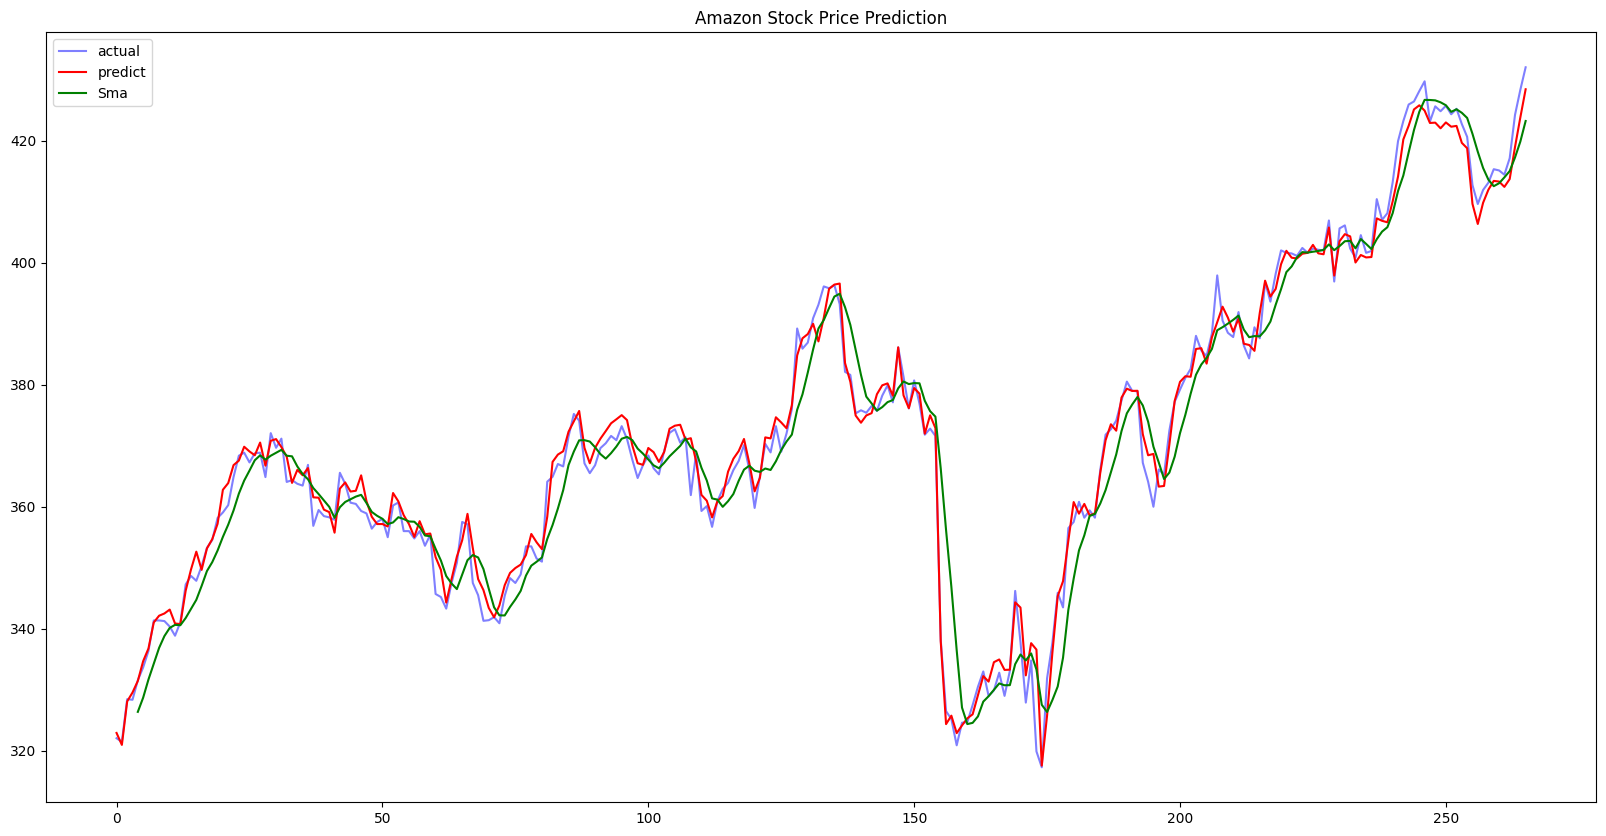

In [15]:
from keras.models import load_model
from matplotlib import pyplot as plt

model = load_model('best_model.h5')

Xt = model.predict(X_test)
# Get scaled close prices (first feature)
# Inverse-transform only the first feature
data_min = scaler.data_min_[0]
data_max = scaler.data_max_[0]
yactual = y_test * (data_max - data_min) + data_min
yactual = pd.Series(yactual)
# yactual = pd.Series(scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1))
# ypred = pd.Series((scaler.inverse_transform(Xt)).reshape(-1))
ypred = Xt[:,0] * (data_max - data_min) + data_min
ypred = pd.Series(ypred)
yema = yactual.ewm(span=3).mean()
signal = pd.Series(index = yactual.index, data = np.zeros(yactual.size))
pdiff = ypred.diff(5)
adiff = yema.diff(5)
for i in yactual.index:
    if (pdiff[i] > 0 and adiff[i] > 0) or (pdiff[i] < 0 and adiff[i] < 0):
        signal[i] = 200
    else:
        signal[i] = 180
del pdiff
del adiff

yactual_sma = yactual.rolling(window=5).mean()#.shift(1)

plt.figure(figsize=(20,10))
plt.plot(yactual, label='actual' , color='blue', alpha=0.5)
plt.plot(ypred, label='predict' , color='red')
plt.plot(yactual_sma, label='Sma', color='green')
#plt.plot(yema)
name = "Amazon Stock Price Prediction"
plt.title(f'{name}')
plt.legend()
plt.show()

Day importnace

In [16]:
# import numpy as np
# import shap

# # Pick sizes
# timesteps  = X_train.shape[1]
# n_features = X_train.shape[2]

# # Background for SHAP (use ~100–300 samples to keep it fast)
# bg_idx = np.random.choice(len(X_train), size=min(200, len(X_train)), replace=False)
# background = X_train[bg_idx]

# # Predict function that accepts 2D (flattened) and reshapes back to 3D
# def predict_flat(X_flat):
#     X3 = X_flat.reshape((-1, timesteps, n_features))
#     return model.predict(X3, verbose=0).ravel()

# # Flatten background and test
# bg_flat   = background.reshape((background.shape[0], -1))
# test_flat = X_test.reshape((X_test.shape[0], -1))

# # Build explainer (KernelExplainer works for any black-box model)
# explainer = shap.KernelExplainer(predict_flat, bg_flat)

# # Explain a single instance (i-th test sample)
# i = 0
# shap_vals = explainer.shap_values(test_flat[i:i+1], nsamples=200)  # increase nsamples for fidelity
# shap_vals = np.array(shap_vals)  # shape (1, n_features_flat)
# sv = shap_vals.reshape(timesteps, n_features)  # reshape back to (timesteps, features)

# # Aggregate importance
# imp_by_timestep = np.abs(sv).mean(axis=1)   # shape (timesteps,)
# imp_by_feature  = np.abs(sv).mean(axis=0)   # shape (n_features,)

# print("Top-5 most influential time steps (0 = oldest, last = most recent):")
# print(np.argsort(-imp_by_timestep)[:5])
# print("Per-feature mean |SHAP|:", imp_by_feature)

# # (Optional) quick plot of timestep importance
# import matplotlib.pyplot as plt
# plt.figure(figsize=(7,3))
# plt.plot(imp_by_timestep)
# plt.title("SHAP importance by timestep")
# plt.xlabel("timestep index"); plt.ylabel("mean |SHAP|")
# plt.tight_layout(); plt.show()


Fearture imporatnce

In [17]:
# feature_names = ['Close', 'LogRet', 'SMA_10', 'EMA_10', 'Volatility_20', 'BB_Upper_20', 'BB_Lower_20', 'VolSpikeFlag'][:8]

# # ==== Compute SHAP for multiple samples (more stable than a single i) ====
# # pick K test samples (random or a specific slice)
# K = min(10, len(X_test))
# np.random.seed(42)
# sample_idx = np.random.choice(len(X_test), size=K, replace=False)

# test_flat_K = X_test[sample_idx].reshape((K, -1))

# # Pick sizes
# timesteps  = X_train.shape[1]
# n_features = X_train.shape[2]

# # Background for SHAP (use ~100–300 samples to keep it fast)
# bg_idx = np.random.choice(len(X_train), size=min(200, len(X_train)), replace=False)
# background = X_train[bg_idx]

# # Predict function that accepts 2D (flattened) and reshapes back to 3D
# def predict_flat(X_flat):
#     X3 = X_flat.reshape((-1, timesteps, n_features))
#     return model.predict(X3, verbose=0).ravel()

# # Flatten background and test
# bg_flat   = background.reshape((background.shape[0], -1))

# import shap
# explainer = shap.KernelExplainer(predict_flat, bg_flat)

# shap_vals_K = explainer.shap_values(test_flat_K, nsamples=200)  # returns list/array
# shap_vals_K = np.array(shap_vals_K)           # shape (K, n_features_flat)
# sv_K = shap_vals_K.reshape(K, timesteps, n_features)

# # ==== Aggregate: by timestep and by feature ====
# imp_by_timestep = np.abs(sv_K).mean(axis=(0, 2))    # shape (timesteps,)
# imp_by_feature  = np.abs(sv_K).mean(axis=(0, 1))    # shape (n_features,)

# print("Top-5 timesteps (0=oldest, last=most recent):", np.argsort(-imp_by_timestep)[:5])
# topf_idx = np.argsort(-imp_by_feature)
# print("Features ranked by mean |SHAP|:")
# for idx in topf_idx:
#     print(f"  {feature_names[idx]:<15s}  {imp_by_feature[idx]:.6f}")

return on money

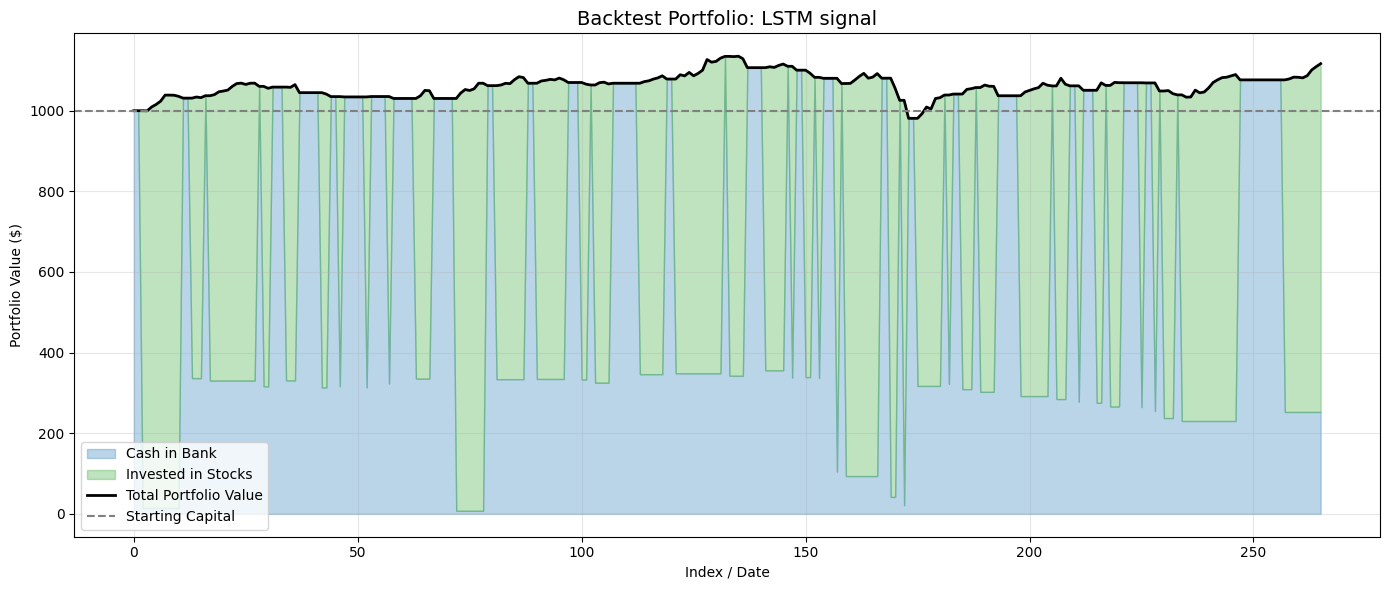

In [18]:
import numpy as np
import pandas as pd


data_min = scaler.data_min_[0]
data_max = scaler.data_max_[0]
yactual = y_test * (data_max - data_min) + data_min
yactual = pd.Series(yactual)
# yactual = pd.Series(scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1))
# ypred = pd.Series((scaler.inverse_transform(Xt)).reshape(-1))
ypred = Xt[:,0] * (data_max - data_min) + data_min
real_signal1 = pd.Series(yactual).diff(1)

Pred_signal1 = pd.Series(ypred).diff(1)
#pd.Series(ema).diff(1)

#sell/buy test
stocks1 = np.zeros((len(Pred_signal1), 1))
stocks2 = np.zeros((len(Pred_signal1), 1))

bank1 = np.zeros((len(Pred_signal1), 1))

bank1[0] = 1000

for i in Pred_signal1.index:
    if i == 0:  continue
    # print(f'signal {i} : {Pred_signal1[i]/1 - Pred_signal1[i]%1}', end = ' | ')
    # print(f'real_signal1 {i} : {real_signal1[i]/1 - real_signal1[i]%1}')
    if Pred_signal1[i] > 1:
        # print(f'buy : money : {bank1[i-1]} / price {yactual[i]}', end = ' | ')
        stocks1[i] = stocks1[i-1] + (bank1[i-1] / yactual[i] ) - (bank1[i-1] / yactual[i] )%1
        # print(f'stocks {i} : {stocks1[i]}')
        bank1[i] = bank1[i-1] - ((bank1[i-1] / yactual[i] ) - (bank1[i-1] / yactual[i] )%1) * yactual[i]

        stocks2[i] = stocks1[i]  * yactual[i]

    elif (Pred_signal1[i] < -1):

        # print(f'sell: Stocks {stocks1[i-1]} * price {yactual[i]}', end = ' | ')
        stocks1[i] = 0
        stocks2[i] = stocks1[i]  * yactual[i]

        bank1[i] = bank1[i-1] + stocks1[i-1] * yactual[i]
        # print(f'bank {i} : {bank1[i]}')
    else:
        # print(f'nothing : bank {bank1[i-1]} , stocks {stocks1[i-1]}')
        stocks1[i] = stocks1[i-1]
        stocks2[i] = stocks1[i]  * yactual[i]

        bank1[i] = bank1[i-1]
    # if i > 6: break

# stocks1 = stocks1 * yactual        
# plt.plot(stocks2)
# plt.plot(bank1)
# plt.show()
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Convert results into Pandas Series for easier plotting ---
idx = Pred_signal1.index
stocks_val = pd.Series((stocks1.flatten() * yactual.values), index=idx, name="Stock Value")
cash_val   = pd.Series(bank1.flatten(), index=idx, name="Cash")
total_val  = stocks_val + cash_val

# Identify buy and sell days from your logic
buy_days  = idx[Pred_signal1 > 1]
sell_days = idx[Pred_signal1 < -1]

# --- Plot ---
plt.figure(figsize=(14, 6))

# Cash balance in blue
plt.fill_between(idx, 0, cash_val, color="tab:blue", alpha=0.3, label="Cash in Bank")

# Stock holdings in green
plt.fill_between(idx, cash_val, total_val, color="tab:green", alpha=0.3, label="Invested in Stocks")

# Total portfolio line
plt.plot(total_val, color="black", linewidth=2, label="Total Portfolio Value")

# Buy markers
# plt.scatter(buy_days, total_val.loc[buy_days], 
            # marker="^", color="green", s=90, label="Buy Signal")

# Sell markers
# plt.scatter(sell_days, total_val.loc[sell_days], 
            # marker="v", color="red", s=90, label="Sell Signal")

# Add labels and grid
plt.axhline(1000, color="gray", linestyle="--", label="Starting Capital")
plt.title("Backtest Portfolio: LSTM signal", fontsize=14)
plt.xlabel("Index / Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Test deployment

In [19]:
import os
import json
import argparse
from dataclasses import dataclass, asdict
from typing import List, Tuple

import numpy as np
import pandas as pd
import joblib
import yfinance as yf

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATE_COL = "Date"

# -------------------------
# Feature Engineering block
# -------------------------

class CustomFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Matches the user's feature function:
      - keep subset of ['Open','High','Low','Close','Volume']
      - LogRet
      - SMA_10, EMA_10
      - Volatility_10, Volatility_20 (std of LogRet)
      - Bollinger 20: BB_Mid_20, BB_Upper_20, BB_Lower_20
      - Volume_z20 (z-score), VolSpikeFlag (>=3)
    Drops rows with NaNs introduced by rolling.
    """
    def __init__(self):
        self.feature_names_: List[str] = []

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        df = X.copy()
        # ensure required cols subset
        cols = [c for c in ["Open","High","Low","Close","Volume"] if c in df.columns]
        df = df[cols].dropna()

        # 2) Log returns
        if "Close" in df.columns:
            df["LogRet"] = np.log(df["Close"] / df["Close"].shift(1))

        # 3) Moving averages
        if "Close" in df.columns:
            df["SMA_10"] = df["Close"].rolling(10, min_periods=10).mean()
            df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

        # 4) Volatility from log returns
        if "LogRet" in df.columns:
            df["Volatility_10"] = df["LogRet"].rolling(10, min_periods=10).std()
            df["Volatility_20"] = df["LogRet"].rolling(20, min_periods=20).std()

        # 5) Bollinger Bands (20)
        if "Close" in df.columns:
            mid = df["Close"].rolling(20, min_periods=20).mean()
            sd  = df["Close"].rolling(20, min_periods=20).std()
            df["BB_Mid_20"]   = mid
            df["BB_Upper_20"] = mid + 2*sd
            df["BB_Lower_20"] = mid - 2*sd

        # 6) Volume outlier flag
        if "Volume" in df.columns:
            vmean = df["Volume"].rolling(20, min_periods=20).mean()
            vstd  = df["Volume"].rolling(20, min_periods=20).std()
            eps = 1e-12
            df["Volume_z20"]  = (df["Volume"] - vmean) / (vstd + eps)
            df["VolSpikeFlag"] = (df["Volume_z20"] >= 3.0).astype(int)

        # Drop rows with NaNs introduced by rolling
        df = df.dropna()

        self.feature_names_ = list(df.columns)
        return df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_, dtype=object)

def build_sklearn_pipeline() -> Pipeline:
    return Pipeline(steps=[("fe", CustomFeatureEngineer())])

# ----------------------
# Sequence preparation
# ----------------------

def make_sequences(X: np.ndarray, y: np.ndarray, window: int, horizon: int) -> Tuple[np.ndarray, np.ndarray]:
    Xs, ys = [], []
    for i in range(len(X) - window - horizon + 1):
        Xs.append(X[i:i+window])
        ys.append(y[i + window + horizon - 1])
    return np.asarray(Xs), np.asarray(ys)

# -------------
# LSTM model
# -------------

def build_lstm(input_shape: Tuple[int,int]) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # regression on next price
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="mse",
                  metrics=["mae"])
    return model

# --------
# Helpers
# --------

def fetch_ohlcv(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(ticker, start=start, end=end, interval="1d", auto_adjust=False, progress=False)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")
    df = df.dropna().copy()
    df.index.name = DATE_COL
    return df

@dataclass
class Meta:
    ticker: str
    start: str
    end: str
    train_ratio: float
    window: int
    horizon: int
    feature_cols: List[str]
    n_train_samples: int
    n_test_samples: int
    x_scaler: str = "MinMax(0,1)"
    y_scaler: str = "MinMax(0,1)"
    target_col: str = "Close"


In [ ]:
# Main train routine
# -------------------

def train_pipeline(ticker: str, start: str, end: str, train_ratio: float,
                   window: int, horizon: int, epochs1: int = 10, batchsize1: int = 16,
                   models_dir: str = "models", artifacts_dir: str = "artifacts"):

    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(artifacts_dir, exist_ok=True)

    # 1) Data
    # raw = fetch_ohlcv(ticker, start, end)
    start1 = datetime(2015, 1, 1)
    end1 = datetime.now()
    raw = yf.download(ticker,start=start,end=end)#"TSCO.L", start=start1, end=end1)

    # 2) Feature Engineering via sklearn pipeline
    sk_pipe = build_sklearn_pipeline()
    feats: pd.DataFrame = sk_pipe.fit_transform(raw)
    feats.index.name = DATE_COL

    # 3) Save engineered features for inspection
    feats.to_csv(os.path.join(artifacts_dir, f"{ticker}_features.csv"))

    # 4) Choose feature columns (keep all engineered numerics)
    feature_cols = list(feats.columns)

    # 5) Build X (all features) and y (Close)
    X_all = feats[feature_cols].values.astype(float)
    if "Close" not in feats.columns:
        raise ValueError("Engineered features do not contain 'Close' column for target scaling. Include it in features.")
    y_all = feats["Close"].values.astype(float).reshape(-1, 1)

    # 6) Scalers
    x_scaler = MinMaxScaler(feature_range=(0,1))
    X_scaled = x_scaler.fit_transform(X_all)

    y_scaler = MinMaxScaler(feature_range=(0,1))
    y_scaled = y_scaler.fit_transform(y_all).ravel()

    # 7) Train/Test split (sequential)
    n = len(feats)
    split_idx = int(n * train_ratio)
    X_train_raw, X_test_raw = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train_raw, y_test_raw = y_scaled[:split_idx], y_scaled[split_idx:]

    # 8) Make sequences
    X_train, y_train = make_sequences(X_train_raw, y_train_raw, window, horizon)
    X_test,  y_test  = make_sequences(X_test_raw,  y_test_raw,  window, horizon)

    # 9) Model
    model = build_lstm((X_train.shape[1], X_train.shape[2]))
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(os.path.join(models_dir, "lstm_model.h5"), monitor="val_loss",
                                        save_best_only=True, save_weights_only=False)
    ]
    history = model.fit(
        X_train, y_train,
        # validation_split=0.1,
        validation_data=(X_test, y_test),
        epochs=epochs1,
        batch_size=batchsize1,
        verbose=1,
        callbacks=callbacks
    )
    
    # Load best model from checkpoint
    model = keras.models.load_model(os.path.join(models_dir, "lstm_model.h5"))

    # 10) Save final model (best already saved via checkpoint, but we also save current)
    model.save(os.path.join(models_dir, "lstm_model_last.h5"))

    # 11) Save scalers and sklearn pipeline
    joblib.dump(x_scaler, os.path.join(models_dir, "x_scaler.pkl"))
    joblib.dump(y_scaler, os.path.join(models_dir, "y_scaler.pkl"))
    joblib.dump(sk_pipe,   os.path.join(models_dir, "sk_pipeline.pkl"))

    # 12) Save sequences & metadata
    np.save(os.path.join(artifacts_dir, "X_train.npy"), X_train)
    np.save(os.path.join(artifacts_dir, "y_train.npy"), y_train)
    np.save(os.path.join(artifacts_dir, "X_test.npy"),  X_test)
    np.save(os.path.join(artifacts_dir, "y_test.npy"),  y_test)

    meta = Meta(
        ticker=ticker, start=start, end=end,
        train_ratio=train_ratio, window=window, horizon=horizon,
        feature_cols=feature_cols,
        n_train_samples=int(len(X_train)),
        n_test_samples=int(len(X_test))
    )
    with open(os.path.join(artifacts_dir, "metadata.json"), "w") as f:
        json.dump(asdict(meta), f, indent=2)

    # 13) Return basic results
    train_loss = float(history.history["loss"][-1])
    val_loss = float(history.history["val_loss"][-1])
    return {
        # "models_dir": models_dir,
        # 'X_scaler': os.path.join(models_dir, "x_scaler.pkl"),
        # 'y_scaler': os.path.join(models_dir, "y_scaler.pkl"),
        # 'xtrain': os.path.join(artifacts_dir, "X_train.npy"),
        # 'ytrain': os.path.join(artifacts_dir, "y_train.npy"),
        # 'xtest': os.path.join(artifacts_dir, "X_test.npy"),
        # 'ytest': os.path.join(artifacts_dir, "y_test.npy"),
        
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "train_loss": train_loss,
        "val_loss": val_loss,
        # "feature_cols": feature_cols
    }


In [24]:
import os, json, io
import numpy as np
import pandas as pd
import joblib
import matplotlib
matplotlib.use("Agg")              # headless backend is fine
import matplotlib.pyplot as plt
from tensorflow import keras
from PIL import Image


MODELS_DIR = "models"
ARTIFACTS_DIR = "artifacts"

def plot_result():
    """
    Load saved artifacts (model + y_scaler + test sequences),
    inverse-scale, align dates, compute SMA/EMA, plot to PNG bytes,
    and return (image, metrics) for Gradio [Image, JSON].
    """
    # --- paths ---
    model_path   = os.path.join(MODELS_DIR, "lstm_model.h5")
    yscaler_path = os.path.join(MODELS_DIR, "y_scaler.pkl")
    Xtest_path   = os.path.join(ARTIFACTS_DIR, "X_test.npy")
    ytest_path   = os.path.join(ARTIFACTS_DIR, "y_test.npy")
    meta_path    = os.path.join(ARTIFACTS_DIR, "metadata.json")

    # --- load ---
    model    = keras.models.load_model(model_path)
    y_scaler = joblib.load(yscaler_path)
    X_test   = np.load(Xtest_path)     # (n_samples, window, n_features)
    y_test   = np.load(ytest_path)     # (n_samples,) scaled

    with open(meta_path, "r") as f:
        meta = json.load(f)
    window   = int(meta.get("window", 60))
    horizon  = int(meta.get("horizon", 1))
    ticker   = meta.get("ticker", "TICKER")
    tr_ratio = float(meta.get("train_ratio", 0.8))

    # dates from engineered features CSV (if available)
    feats_csv = os.path.join(ARTIFACTS_DIR, f"{ticker}_features.csv")
    if os.path.exists(feats_csv):
        feats = pd.read_csv(feats_csv)
        first_col = feats.columns[0]
        feats[first_col] = pd.to_datetime(feats[first_col], errors="coerce")
        feats = feats.dropna(subset=[first_col]).set_index(first_col)
        n = len(feats)
        split_idx = int(n * tr_ratio)
        start_idx = split_idx + window + horizon - 1
        idx = feats.index[start_idx:start_idx+len(y_test)]
    else:
        idx = pd.RangeIndex(0, len(y_test), 1)

    # predict (scaled)
    ypred_s = model.predict(X_test, verbose=0).ravel()

    # inverse-scale
    ypred   = y_scaler.inverse_transform(ypred_s.reshape(-1,1)).ravel()
    yactual = y_scaler.inverse_transform(y_test.reshape(-1,1)).ravel()

    # align
    m = min(len(idx), len(ypred), len(yactual))
    idx = pd.Index(idx[-m:])
    s_actual = pd.Series(yactual[-m:], index=idx, name="actual")
    s_pred   = pd.Series(ypred[-m:],   index=idx, name="lstm")
    sma_window = 5
    # baselines
    sma = s_actual.rolling(window=sma_window, min_periods=sma_window).mean().rename(f"SMA{sma_window}")
    ema = s_actual.ewm(span=sma_window, adjust=False).mean().rename(f"EMA{sma_window}")

    dfm = pd.concat([s_actual, s_pred, sma, ema], axis=1).dropna()

    # metrics
    rmse = float(np.sqrt(((dfm["actual"] - dfm["lstm"])**2).mean()))
    mae  = float((dfm["actual"] - dfm["lstm"]).abs().mean())
    metrics = {"ticker": ticker, "window": window, "horizon": horizon, "RMSE": rmse, "MAE": mae}

    # plot → PNG bytes (NO plt.show())
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(dfm.index, dfm["actual"], label="Actual", linewidth=1.6)
    ax.plot(dfm.index, dfm["lstm"],   label=f"LSTM (window={window})", alpha=0.9)
    ax.plot(dfm.index, dfm[f"SMA{sma_window}"], label=f"SMA {sma_window}", linestyle="--")
    ax.plot(dfm.index, dfm[f"EMA{sma_window}"], label=f"EMA {sma_window}", linestyle="--")
    ax.set_title(f"{ticker} Prediction")
    ax.set_xlabel("Date"); ax.set_ylabel("Price"); ax.grid(True); ax.legend()
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120)
    plt.close(fig)
    buf.seek(0)
    
    # Convert buffer to a PIL image for Gradio
    pil_img = Image.open(buf).convert("RGB")
    return pil_img, 0#metrics

In [ ]:
def plot_strategy_local(start_capital=1000.0, threshold=1.0):
    """
    Reproduces your buy/sell test using LSTM predicted price diffs.
    Returns (PIL image, metrics dict) for Gradio [Image, JSON].
    """
    # --- paths & loads ---
    model_path   = os.path.join(MODELS_DIR, "lstm_model.h5")
    yscaler_path = os.path.join(MODELS_DIR, "y_scaler.pkl")
    Xtest_path   = os.path.join(ARTIFACTS_DIR, "X_test.npy")
    ytest_path   = os.path.join(ARTIFACTS_DIR, "y_test.npy")
    meta_path    = os.path.join(ARTIFACTS_DIR, "metadata.json")

    model    = keras.models.load_model(model_path)
    y_scaler = joblib.load(yscaler_path)
    X_test   = np.load(Xtest_path)     # (n_samples, window, n_features)
    y_test   = np.load(ytest_path)     # (n_samples,) scaled

    with open(meta_path, "r") as f:
        meta = json.load(f)
    window   = int(meta.get("window", 60))
    horizon  = int(meta.get("horizon", 1))
    ticker   = meta.get("ticker", "TICKER")
    tr_ratio = float(meta.get("train_ratio", 0.8))

    # --- build a proper datetime index for test portion ---
    feats_csv = os.path.join(ARTIFACTS_DIR, f"{ticker}_features.csv")
    if os.path.exists(feats_csv):
        feats = pd.read_csv(feats_csv)
        first_col = feats.columns[0]
        feats[first_col] = pd.to_datetime(feats[first_col], errors="coerce")
        feats = feats.dropna(subset=[first_col]).set_index(first_col)
        n = len(feats)
        split_idx = int(n * tr_ratio)
        start_idx = split_idx + window + horizon - 1
        idx = feats.index[start_idx:start_idx + len(y_test)]
    else:
        idx = pd.RangeIndex(0, len(y_test), 1)

    # --- predict (scaled) & inverse-scale to prices ---
    ypred_s = model.predict(X_test, verbose=0).ravel()
    ypred   = y_scaler.inverse_transform(ypred_s.reshape(-1,1)).ravel()
    yactual = y_scaler.inverse_transform(y_test.reshape(-1,1)).ravel()

    # --- align lengths & convert to Series ---
    m = min(len(idx), len(ypred), len(yactual))
    idx = pd.Index(idx[-m:])
    ypred = pd.Series(ypred[-m:], index=idx)
    yactual = pd.Series(yactual[-m:], index=idx)

    # --- your signal: price diff of predictions ---
    Pred_signal1 = ypred.diff(1)  # buy if > threshold, sell if < -threshold

    # --- state arrays (same as your loop but with safer floor math) ---
    npts = len(Pred_signal1)
    stocks1 = np.zeros((npts,), dtype=np.float64)  # number of shares
    bank1   = np.zeros((npts,), dtype=np.float64)
    bank1[0] = float(start_capital)

    buy_days  = []
    sell_days = []

    for i in range(1, npts):
        sig = Pred_signal1.iloc[i]
        price = yactual.iloc[i]

        if sig > threshold:
            # buy as many whole shares as possible with all cash
            shares_to_buy = np.floor(bank1[i-1] / price)
            stocks1[i] = stocks1[i-1] + shares_to_buy
            bank1[i]   = bank1[i-1] - shares_to_buy * price
            buy_days.append(yactual.index[i])
        elif sig < -threshold:
            # sell all
            bank1[i]   = bank1[i-1] + stocks1[i-1] * price
            stocks1[i] = 0.0
            sell_days.append(yactual.index[i])
        else:
            # hold
            stocks1[i] = stocks1[i-1]
            bank1[i]   = bank1[i-1]

    # current value of stock position
    stocks_val = pd.Series(stocks1 * yactual.values, index=yactual.index, name="Stock Value")
    cash_val   = pd.Series(bank1, index=yactual.index, name="Cash")
    total_val  = (stocks_val + cash_val).rename("Total")

    # --- plot (stacked areas like your example) ---
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.fill_between(total_val.index, 0, cash_val.values, alpha=0.30, label="Cash in Bank")
    ax.fill_between(total_val.index, cash_val.values, total_val.values, alpha=0.30, label="Invested in Stocks")
    ax.plot(total_val.index, total_val.values, color="black", linewidth=2, label="Total Portfolio Value")
    ax.axhline(start_capital, color="gray", linestyle="--", label="Starting Capital")

    # Optional markers (commented out to keep it clean)
    # ax.scatter(buy_days, total_val.loc[buy_days], marker="^", s=70, label="Buy", color="green")
    # ax.scatter(sell_days, total_val.loc[sell_days], marker="v", s=70, label="Sell", color="red")

    ax.set_title(f"Backtest Portfolio: LSTM Signal ({ticker})")
    ax.set_xlabel("Date"); ax.set_ylabel("Portfolio Value")
    ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout()

    # -> PIL image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120)
    plt.close(fig)
    buf.seek(0)
    pil_img = Image.open(buf).convert("RGB")

    # --- metrics ---
    trades = len(buy_days) + len(sell_days)
    total_return = float(total_val.iloc[-1] / start_capital - 1.0)
    metrics = {
        "ticker": ticker,
        "window": window,
        "horizon": horizon,
        "start_capital": float(start_capital),
        "final_portfolio": float(total_val.iloc[-1]),
        "total_return": total_return,
        "num_buys": len(buy_days),
        "num_sells": len(sell_days),
        "threshold": float(threshold)
    }

    return pil_img, metrics


C:\Users\Ehsan\AppData\Local\Temp\ipykernel_16252\372622140.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  feats[first_col] = pd.to_datetime(feats[first_col], errors="coerce")
C:\Users\Ehsan\AppData\Local\Temp\ipykernel_16252\372622140.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  feats[first_col] = pd.to_datetime(feats[first_col], errors="coerce")
C:\Users\Ehsan\AppData\Local\Temp\ipykernel_16252\1830579846.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  feats[first_col] = pd.to_datetime(feats[first_col], errors="coerce")


In [ ]:
# --- Gradio UI only (keep your existing imports & functions) ---
import gradio as gr

with gr.Blocks(title="Stock Market Prediction") as demo:
    gr.Markdown("# Stock Market Prediction")

    with gr.Row():
        ticker = gr.Textbox(label="Ticker", value="TSCO.L")
        start = gr.Textbox(label="Start Date", value="2015-01-01")
        end = gr.Textbox(label="End Date", value="2025-01-01")

    with gr.Row():
        train_ratio = gr.Slider(minimum=0.4, maximum=0.9, value=0.8, step=0.05, label="Training Ratio")
        window = gr.Slider(minimum=30, maximum=150, value=120, step=30, label="Window Size")
        horizon = gr.Number(value=1, label="Horizon")

    run_button = gr.Button("Run Model")
    output = gr.JSON(label="Training Output")
    # Call your already-defined functions
    run_button.click(
        fn=train_pipeline,              # or run_model if you wrapped it
        inputs=[ticker, start, end, train_ratio, window, horizon],
        outputs=output
    )

    # --- Prediction plot (PIL + JSON) ---
    gr.Markdown("## Plot Prediction vs SMA")
    plot_button = gr.Button("Plot Results")
    plot_image  = gr.Image(type="pil", label="Prediction vs SMA/EMA")
    plot_metrics = gr.JSON(label="Metrics")

    plot_button.click(
        fn=plot_result,                 # must return (PIL_image, dict)
        inputs=None,
        outputs=[plot_image, plot_metrics]
    )

    gr.Markdown("## Strategy Backtest (LSTM signal)")

    # Inputs row
    with gr.Row():
        strat_threshold = gr.Slider(minimum=0.1, maximum=5.0, step=0.1, value=1.0,
                                label="Signal Threshold (Δpred)")
        strat_capital   = gr.Number(value=1000, label="Starting Capital")
        strategy_button = gr.Button("Run Strategy Backtest")

    # Outputs row
    with gr.Row():
        strategy_image   = gr.Image(type="pil", label="Backtest Portfolio")
        strategy_metrics = gr.JSON(label="Backtest Metrics")
    

    strategy_button.click(
        fn=lambda thr, cap: plot_strategy_local(start_capital=float(cap), threshold=float(thr)),
        inputs=[strat_threshold, strat_capital],
        outputs=[strategy_image, strategy_metrics]
    )

demo.launch()


* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.


[*********************100%***********************]  1 of 1 completed


Epoch 1/10
118/118 [==============================] - 9s 65ms/step - loss: 0.0083 - mae: 0.0638 - val_loss: 0.0012 - val_mae: 0.0278
Epoch 2/10
118/118 [==============================] - 7s 59ms/step - loss: 0.0031 - mae: 0.0426 - val_loss: 0.0027 - val_mae: 0.0424
Epoch 3/10
118/118 [==============================] - 6s 48ms/step - loss: 0.0026 - mae: 0.0385 - val_loss: 0.0039 - val_mae: 0.0531
Epoch 4/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0021 - mae: 0.0348 - val_loss: 0.0068 - val_mae: 0.0756
Epoch 5/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0020 - mae: 0.0338 - val_loss: 0.0056 - val_mae: 0.0680
Epoch 6/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0017 - mae: 0.0312 - val_loss: 0.0039 - val_mae: 0.0550
Epoch 7/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0016 - mae: 0.0302 - val_loss: 0.0024 - val_mae: 0.0397


C:\Users\Ehsan\AppData\Local\Temp\ipykernel_16252\372622140.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  feats[first_col] = pd.to_datetime(feats[first_col], errors="coerce")
Traceback (most recent call last):
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\queueing.py", line 626, in process_events
    response = await route_utils.call_process_api(
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\route_utils.py", line 350, in call_process_api
    output = await app.get_blocks().process_api(
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\blocks.py", line 2235, in process_api
    result = await self.call_function(
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\blocks.py", line 1746, in

Epoch 1/10
118/118 [==============================] - 5s 29ms/step - loss: 0.0142 - mae: 0.0799 - val_loss: 0.0026 - val_mae: 0.0401
Epoch 2/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0035 - mae: 0.0457 - val_loss: 0.0026 - val_mae: 0.0421
Epoch 3/10
118/118 [==============================] - 3s 28ms/step - loss: 0.0027 - mae: 0.0395 - val_loss: 0.0012 - val_mae: 0.0272
Epoch 4/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0022 - mae: 0.0359 - val_loss: 9.0963e-04 - val_mae: 0.0242
Epoch 5/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0020 - mae: 0.0342 - val_loss: 0.0056 - val_mae: 0.0663
Epoch 6/10
118/118 [==============================] - 3s 26ms/step - loss: 0.0019 - mae: 0.0333 - val_loss: 0.0032 - val_mae: 0.0472
Epoch 7/10
118/118 [==============================] - 3s 27ms/step - loss: 0.0018 - mae: 0.0326 - val_loss: 0.0054 - val_mae: 0.0647
Epoch 8/10
118/118 [==============================] - 3s 26ms/ste

C:\Users\Ehsan\AppData\Local\Temp\ipykernel_16252\372622140.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  feats[first_col] = pd.to_datetime(feats[first_col], errors="coerce")
Traceback (most recent call last):
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\queueing.py", line 626, in process_events
    response = await route_utils.call_process_api(
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\route_utils.py", line 350, in call_process_api
    output = await app.get_blocks().process_api(
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\blocks.py", line 2235, in process_api
    result = await self.call_function(
  File "c:\Users\Ehsan\AppData\Local\Programs\Python\Python310\lib\site-packages\gradio\blocks.py", line 1746, in